### Importação dos dados



In [1]:
import pandas as pd

url = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_1.csv"
url2 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_2.csv"
url3 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_3.csv"
url4 = "https://raw.githubusercontent.com/alura-es-cursos/challenge1-data-science/refs/heads/main/base-de-dados-challenge-1/loja_4.csv"

loja = pd.read_csv(url)
loja2 = pd.read_csv(url2)
loja3 = pd.read_csv(url3)
loja4 = pd.read_csv(url4)

loja.head()


,Produto,Categoria do Produto,Preço,Frete,Data da Compra,Vendedor,Local da compra,Avaliação da compra,Tipo de pagamento,Quantidade de parcelas,lat,lon
0,Assistente virtual,eletronicos,219.08,9.249790,16/01/2021,Pedro Gomes,SP,4,cartao_credito,8,-22.19,-48.79
1,Mesa de jantar,moveis,256.35,11.234305,18/05/2022,Beatriz Moraes,RJ,1,cartao_credito,4,-22.25,-42.66
2,Jogo de tabuleiro,brinquedos,279.51,21.262681,15/03/2021,João Souza,DF,1,cartao_credito,1,-15.83,-47.86
3,Micro-ondas,eletrodomesticos,1009.99,54.667344,03/05/2022,João Souza,RS,4,boleto,1,-30.17,-53.50
4,Cadeira de escritório,moveis,446.99,26.964689,07/11/2020,Larissa Alves,MG,5,boleto,1,-18.10,-44.38


#1. Análise do faturamento


In [2]:
def faturamento(df) -> float:
  return df['Preço'].sum()

In [3]:
fat_1 = faturamento(loja)
fat_2 = faturamento(loja2)
fat_3 = faturamento(loja3)
fat_4 = faturamento(loja4)

relatorio_de_faturamento = pd.DataFrame([fat_1, fat_2, fat_3, fat_4],
                                        index=['Loja_1', 'Loja_2', 'Loja_3', 'Loja_4'],
                                        columns=['Faturamento Bruto']
                                        )

relatorio_de_faturamento

,Faturamento Bruto
Loja_1,1534509.12
Loja_2,1488459.06
Loja_3,1464025.03
Loja_4,1384497.58


<Figure size 800x500 with 0 Axes>

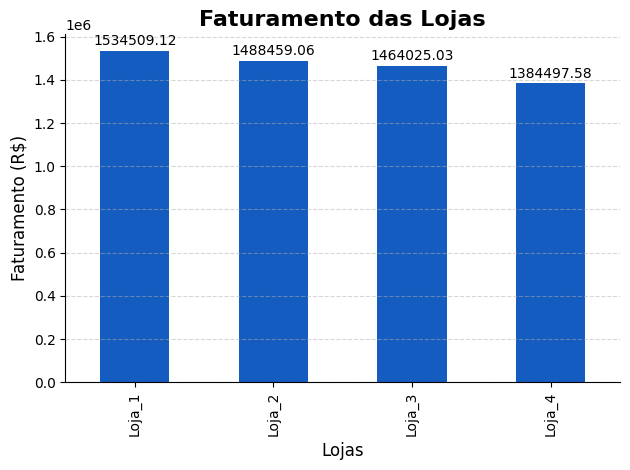

In [4]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

# Gerando grafico

grafico = relatorio_de_faturamento.plot(kind='bar', color='#155cc0', legend=False)

# Titulos
plt.title('Faturamento das Lojas', fontsize=16, fontweight='bold')
plt.xlabel('Lojas', fontsize=12)
plt.ylabel('Faturamento (R$)', fontsize=12)

# linhas de grade eixo Y
plt.grid(axis='y', linestyle='--', alpha=0.5)

# retirando a caixa
grafico.spines['top'].set_visible(False)
grafico.spines['right'].set_visible(False)

# Valores das lojas
for i in grafico.containers:
  grafico.bar_label(i, fmt='%.2f', fontsize=10, label_type='edge', padding=2)

# Apresentação dos graficos
plt.tight_layout()
plt.show();

# 2. Vendas por Categoria


In [5]:
# QUNATIFICANDO QUAL CATEGORIA É MAIS VENDIDA
def mais_vendidos(df) -> pd.DataFrame:
  contagem = df['Categoria do Produto'].value_counts()
  porcentagem = df['Categoria do Produto'].value_counts(normalize=True)*100
  return pd.DataFrame({'Quantidade':contagem, 'Porcentagem': porcentagem.round(2)})

In [6]:
mais_vendidos(loja)


,Quantidade,Porcentagem
Categoria do Produto,,
moveis,465,19.71
eletronicos,448,18.99
brinquedos,324,13.73
eletrodomesticos,312,13.23
esporte e lazer,284,12.04
instrumentos musicais,182,7.72
livros,173,7.33
utilidades domesticas,171,7.25


In [7]:
mais_vendidos(loja2)

,Quantidade,Porcentagem
Categoria do Produto,,
moveis,442,18.74
eletronicos,422,17.89
brinquedos,313,13.27
eletrodomesticos,305,12.93
esporte e lazer,275,11.66
instrumentos musicais,224,9.50
livros,197,8.35
utilidades domesticas,181,7.67


In [8]:
mais_vendidos(loja3)

,Quantidade,Porcentagem
Categoria do Produto,,
moveis,499,21.15
eletronicos,451,19.12
brinquedos,315,13.35
eletrodomesticos,278,11.78
esporte e lazer,277,11.74
livros,185,7.84
instrumentos musicais,177,7.50
utilidades domesticas,177,7.50


In [9]:
mais_vendidos(loja4)

,Quantidade,Porcentagem
Categoria do Produto,,
moveis,480,20.36
eletronicos,451,19.13
brinquedos,338,14.33
esporte e lazer,277,11.75
eletrodomesticos,254,10.77
utilidades domesticas,201,8.52
livros,187,7.93
instrumentos musicais,170,7.21


# 3. Média de Avaliação das Lojas

In [10]:
def avaliacao_da_loja(df) -> float:
  '''
  Foi utilizado o metodo de media ponderada para fazer a avaliação das lojas
  baseado nas avaiçãoes dos clinetes que vão de 1 a 5 na qual as notas com
  maior peso 5 serão multiplicadas por 5 e as outras por seus respectivos valores.
  '''
  contador = df['Avaliação da compra'].value_counts().sort_index()
  avaliacoes = contador.index
  valores = contador.values
  return round(sum(avaliacoes * valores) / len(df['Avaliação da compra']), 2)

In [11]:
ava_1 = avaliacao_da_loja(loja)
ava_2 = avaliacao_da_loja(loja2)
ava_3 = avaliacao_da_loja(loja3)
ava_4 = avaliacao_da_loja(loja4)

df = {'Avaliação Das Lojas':[ava_1, ava_2, ava_3, ava_4]}

avaliacao = pd.DataFrame(df)
avaliacao.index = ['loja_1', 'loja_2', 'loja_3', 'loja_4']
avaliacao

,Avaliação Das Lojas
loja_1,3.98
loja_2,4.04
loja_3,4.05
loja_4,4.00


<Figure size 700x500 with 0 Axes>

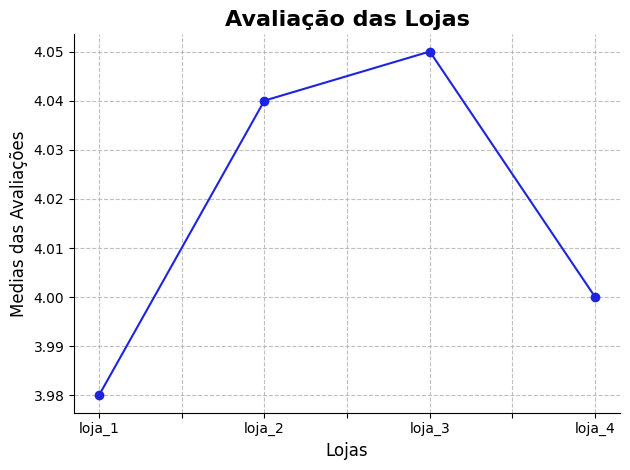

In [12]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

# Criando Grafico
linhas = avaliacao.plot(kind='line', legend=False, marker='o', color='#1D24E0')

# Titulos
plt.title('Avaliação das Lojas', fontsize=16, fontweight='bold')
plt.xlabel('Lojas', fontsize=12)
plt.ylabel('Medias das Avaliações', fontsize=12)

# Grid
plt.grid(linestyle='--', alpha=0.8)

linhas.spines['top'].set_visible(False)
linhas.spines['right'].set_visible(False)

plt.tight_layout()
plt.show();

# 4. Produtos Mais e Menos Vendidos

In [13]:
def produtos_vendidos(df) -> list:
  '''
  Lista dos 5 produtos mais vendidos e os menos vendidos
  '''
  produtos = df['Produto'].value_counts()
  mais_vendidos = produtos.head(1).index[0] # nome do produto
  quantidade_mais_vendida = produtos.head(1).values[0] # quantidade dos produtos

  menos_vendidos = produtos.tail(1).index[0]
  quantidade_menos_vendida = produtos.tail(1).values[0]

  return[
      mais_vendidos, quantidade_mais_vendida, menos_vendidos, quantidade_menos_vendida
  ]

In [14]:
loja_1 = produtos_vendidos(loja)
loja_2 = produtos_vendidos(loja2)
loja_3 = produtos_vendidos(loja3)
loja_4 = produtos_vendidos(loja4)

produtos = pd.DataFrame([loja_1, loja_2, loja_3, loja_4])
produtos.index=['Loja_1', 'Loja_2', 'Loja_3', 'Loja_4']
produtos.columns=['Mais Vendidos', 'Quantidade Mais Vendida', 'Menos Vendidos', 'Quantidade Menos Vendida' ]
produtos

,Mais Vendidos,Quantidade Mais Vendida,Menos Vendidos,Quantidade Menos Vendida
Loja_1,Micro-ondas,60,Celular ABXY,33
Loja_2,Iniciando em programação,65,Jogo de tabuleiro,32
Loja_3,Kit banquetas,57,Blocos de montar,35
Loja_4,Cama box,62,Guitarra,33


# 5. Frete Médio por Loja


In [15]:
def media_do_frete(df) -> float:
  return round(df['Frete'].sum() / len(df['Frete']), 2)

In [16]:
media1 = media_do_frete(loja)
media2 = media_do_frete(loja2)
media3 = media_do_frete(loja3)
media4 = media_do_frete(loja4)

ferte_medio = pd.DataFrame([media1, media2, media3, media4],
                           index=['Loja_1', 'Loja_2', 'Loja_3', 'Loja_4'],
                           columns=['Preço Medio Do Frete']
                           )
ferte_medio

,Preço Medio Do Frete
Loja_1,34.69
Loja_2,33.62
Loja_3,33.07
Loja_4,31.28


<Figure size 800x500 with 0 Axes>

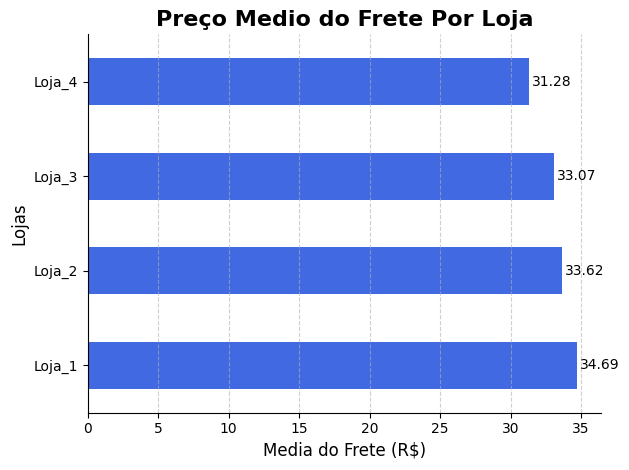

In [17]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

# grafico de colunas
coluna = ferte_medio.plot(kind='barh',color='#4169E1', legend=False)

plt.title('Preço Medio do Frete Por Loja', fontsize=16, fontweight='bold')
plt.xlabel('Media do Frete (R$)', fontsize=12)
plt.ylabel('Lojas', fontsize=12)

# Gride no eixo x
plt.grid(axis='x', linestyle='--', alpha=0.6)

# removendo caixa
coluna.spines['top'].set_visible(False)
coluna.spines['right'].set_visible(False)

# preço do frete
for i in coluna.containers:
  coluna.bar_label(i, fmt='%.2f', fontsize=10, label_type='edge', padding=2)

plt.tight_layout()
plt.show()

# Análise de Desempenho Geográfico

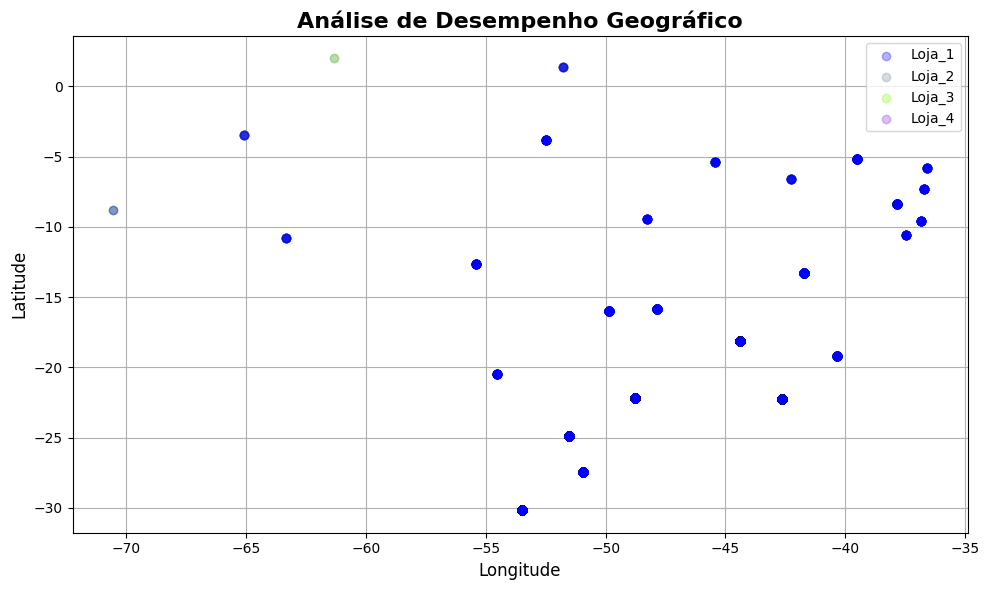

In [19]:
import matplotlib.pyplot as plt

# tamanho da figura
plt.figure(figsize=(10, 6))

# Grafico de disperção alimentado pelos 4 DadaFrames
plt.scatter(loja['lon'], loja['lat'], alpha=0.3, label='Loja_1', color='#0000FF', zorder=4)
plt.scatter(loja2['lon'], loja2['lat'], alpha=0.3, label='Loja_2', color='#778899', zorder=3)
plt.scatter(loja3['lon'], loja3['lat'], alpha=0.3, label='Loja_3', color='#7FFF00', zorder=2)
plt.scatter(loja4['lon'], loja4['lat'], alpha=0.3, label='Loja_4', color='#8A2BE2', zorder=1)

#titulos
plt.title('Análise de Desempenho Geográfico', fontsize=16, fontweight='bold')
plt.xlabel('Longitude', fontsize=12)
plt.ylabel('Latitude', fontsize=12)

plt.grid(True)
plt.legend()

plt.tight_layout()
plt.show()


# Relatório de Conclusão – Challenge Alura Store

## Introdução
Este relatório tem por objetivo analisar as métricas das quatro lojas, a fim de indicar qual delas deverá ser vendida. Essa decisão será fundamentada com base na comparação dos dados analisados, que foram cedidos pelas empresas.

## Métricas avaliadas

| Lojas | Faturamento | Vendas por categoria | Avaliação das Lojas | Produtos Mais Vendidos| Produtos Menos Vendidos| Frete Médio|
|---------|----------|---------|---------|------------|------------|---------|
|LOJA1|1.534.509,12|Moveis 19.71%|3.98|Micro-ondas|Celular ABXY|34.69
|LOJA2|1.488.459,06|Moveis 18.74%|4.04|Iniciando em programação|Jogo de tabuleiro|33.62
|LOJA3|1.464.025,03|Moveis 21.15%|4.05|Kit banquetas|Blocos de montar|33.07
|LOJA4|1.384.497,58|Moveis 20.36%|4.00|Cama box|Guitarra|31.28

## Análise e Interpretação dos Dados
A **Loja 1**, mesmo tendo a menor avaliação entre as quatro (3,98) e o maior frete por produto (34,69 Reais), consegue converter esses indicadores negativos em faturamento. Foi a loja que mais faturou desde sua criação, com um acumulado de R$ 1.534.509,12, indicando que tem potencial para crescer, caso os problemas referentes ao frete e às avaliações sejam resolvidos. Cerca de 19,71% do seu faturamento vem da venda de móveis, sendo esta a maior parcela por categoria. O produto mais vendido é um eletrodoméstico micro-ondas e o menos vendido é um eletrônico celular ABXY.

A **Loja 2** possui bons indicadores, tendo a segunda maior avaliação (4,04) e sendo a segunda loja que mais faturou, com um acumulado de 1.488.459,06 Reais desde sua criação. No entanto, possui o segundo maior frete por produto (R$ 33,62), o que pode ser solucionado com as abordagens corretas. Cerca de 18,74% do seu faturamento vem da venda de móveis. Seu produto mais vendido é “Iniciando em Programação”, da categoria de livros, e o menos vendido é “Jogo de Tabuleiro”, da categoria de brinquedos.

A **Loja 3** apresenta indicadores medianos. Possui a melhor avaliação entre as quatro (4,05) e o segundo menor frete (33,07 Reais). No entanto, tem o segundo menor faturamento (R$ 1.460.025,03), valor que não se distancia muito da Loja 2. Cerca de 21,15% do seu faturamento está atrelado à categoria de móveis, sendo a loja com a maior parcela vinda desse segmento. Seu produto mais vendido é o kit de banquetas e o menos vendido são os blocos de montar, da categoria de brinquedos.

Por fim, a **Loja 4** tem o menor faturamento entre as quatro (1.384.497,58 Reais) e a segunda pior avaliação (4,00). Porém possuir o menor frete médio por produto (R$ 31,28). Aproximadamente 20,36% do seu faturamento vem da categoria de móveis. Seu produto mais vendido é a cama box, e o menos vendido é a guitarra, da categoria de instrumentos musicais.

## Conclusão
A loja escolhida para venda é a **Loja 4**, pois apresentou os piores indicadores entre as quatro, com base nos gráficos e nos relatórios apresentados acima. Com o menor faturamento e a segunda pior avaliação, mesmo tendo o menor frete por produto, não conseguiu transformá-lo em vantagem competitiva, o que indica possíveis falhas estruturais.

## Observações Finais
Com base na análise de desempenho geográfico, foi identificado que as lojas atuam na mesma região, competindo entre si, com um catálogo de produtos praticamente idêntico. Minha recomendação é que cada loja seja especializada (nichada) de acordo com as categorias e os produtos mais vendidos, reduzindo a competição e melhorando a performance individual de cada uma. Isso permite que cada loja foque no que faz melhor, aumentando a fidelização dos clientes.